# Principal Component Analysis (PCA) from Scratch 📉

In this notebook, we implement **Principal Component Analysis (PCA)**, a powerful unsupervised technique for dimensionality reduction.

## 📖 Theoretical Background

PCA reduces the dimensionality of a dataset while preserving as much variance as possible.

### 1. Standardization
Data must be centered by subtracting the mean of each feature:
$$X_{\text{centered}} = X - \mu$$

### 2. Covariance Matrix
Compute the covariance matrix to understand how features vary together:
$$C = \frac{1}{n-1} X_{\text{centered}}^T X_{\text{centered}}$$

### 3. Eigen Decomposition
Compute the eigenvalues ($\lambda$) and eigenvectors ($v$) of the covariance matrix:
$$Cv = \lambda v$$
Eigenvectors represent the directions of maximum variance (principal components), and eigenvalues represent the magnitude of variance in those directions.

### 4. Projection
Sort the eigenvectors by decreasing eigenvalues, select the top $k$ components, and project the data:
$$X_{\text{projected}} = X_{\text{centered}} W$$
Where $W$ is the matrix containing the top $k$ eigenvectors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

np.random.seed(42)

## 🏗️ The Implementation

In [2]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        
    def fit(self, X):
        # 1. Center the data
        self.mean = np.mean(X, axis=0)
        X = X - self.mean
        
        # 2. Compute covariance matrix
        # Note: np.cov expects features as rows, so we transpose X
        cov = np.cov(X.T)
        
        # 3. Calculate eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        
        # 4. Sort eigenvectors by descending eigenvalues
        # eigenvectors are stored as columns
        eigenvectors = eigenvectors.T
        idxs = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idxs]
        eigenvectors = eigenvectors[idxs]
        
        # 5. Store first n_components
        self.components = eigenvectors[0:self.n_components]
        
    def transform(self, X):
        # Project data
        X = X - self.mean
        return np.dot(X, self.components.T)


## 🧪 Data Generation and Training

We will reduce the 4-dimensional Iris dataset down to 2 dimensions for visualization.

In [3]:
data = load_iris()
X = data.data
y = data.target

# Project from 4D to 2D
pca = PCA(2)
pca.fit(X)
X_projected = pca.transform(X)

print(f"Shape of X: {X.shape}")
print(f"Shape of transformed X: {X_projected.shape}")

Shape of X: (150, 4)
Shape of transformed X: (150, 2)


## 📊 Visualization

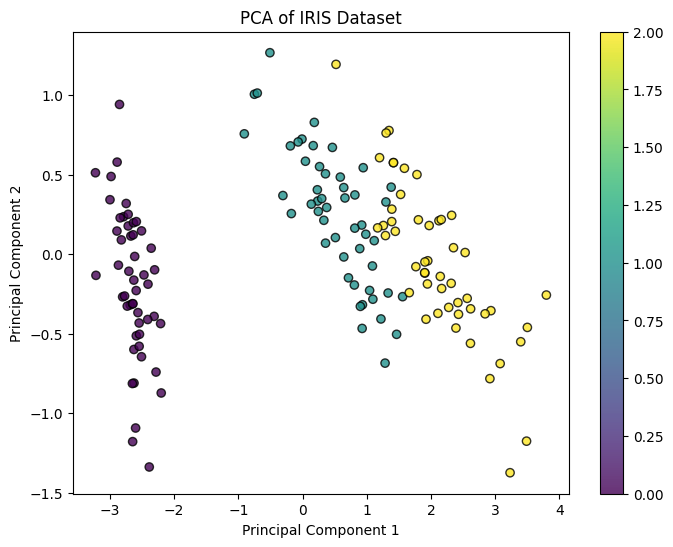

In [4]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_projected[:, 0], X_projected[:, 1], c=y, cmap="viridis", edgecolors='k', alpha=0.8)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of IRIS Dataset")
plt.colorbar(scatter)
plt.show()

## 📊 Additional Visualizations

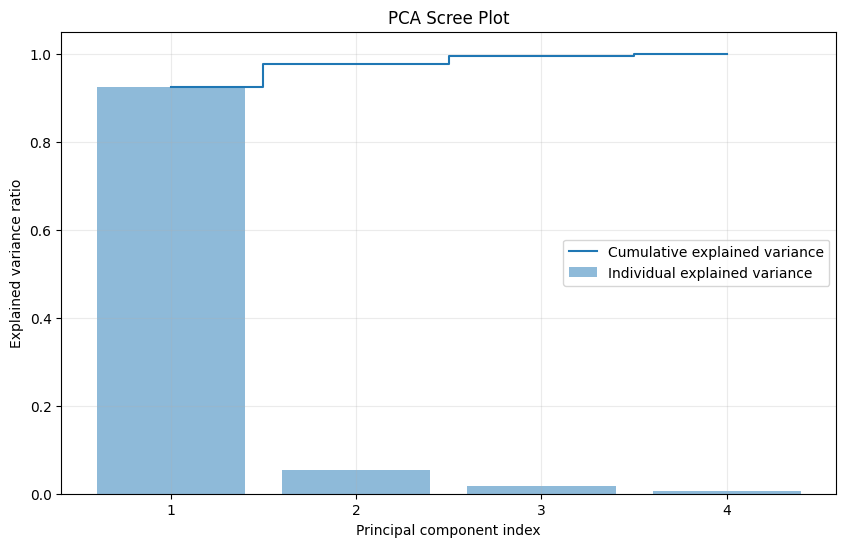

In [5]:
from sklearn.decomposition import PCA

# Fit PCA on the current dataset
pca = PCA(n_components=X.shape[1])
pca.fit(X)

# Correct attribute: explained_variance_ratio_
explained_variance_ratio = pca.explained_variance_ratio_
components = np.arange(1, len(explained_variance_ratio) + 1)

plt.figure(figsize=(10, 6))

# Bar chart: individual explained variance
plt.bar(
    components,
    explained_variance_ratio,
    alpha=0.5,
    align='center',
    label='Individual explained variance'
 )

# Step chart: cumulative explained variance
plt.step(
    components,
    np.cumsum(explained_variance_ratio),
    where='mid',
    label='Cumulative explained variance'
 )

plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.xticks(components)
plt.ylim(0, 1.05)
plt.legend(loc='best')
plt.title('PCA Scree Plot')
plt.grid(alpha=0.25)
plt.show()

## 🌀 Alternative Implementation: Kernel PCA
Standard PCA is a linear projection. When data is not linearly separable, we can use the **Kernel Trick** to project it into a higher-dimensional space where it is linearly separable, and then perform PCA. We will implement an RBF Kernel PCA.

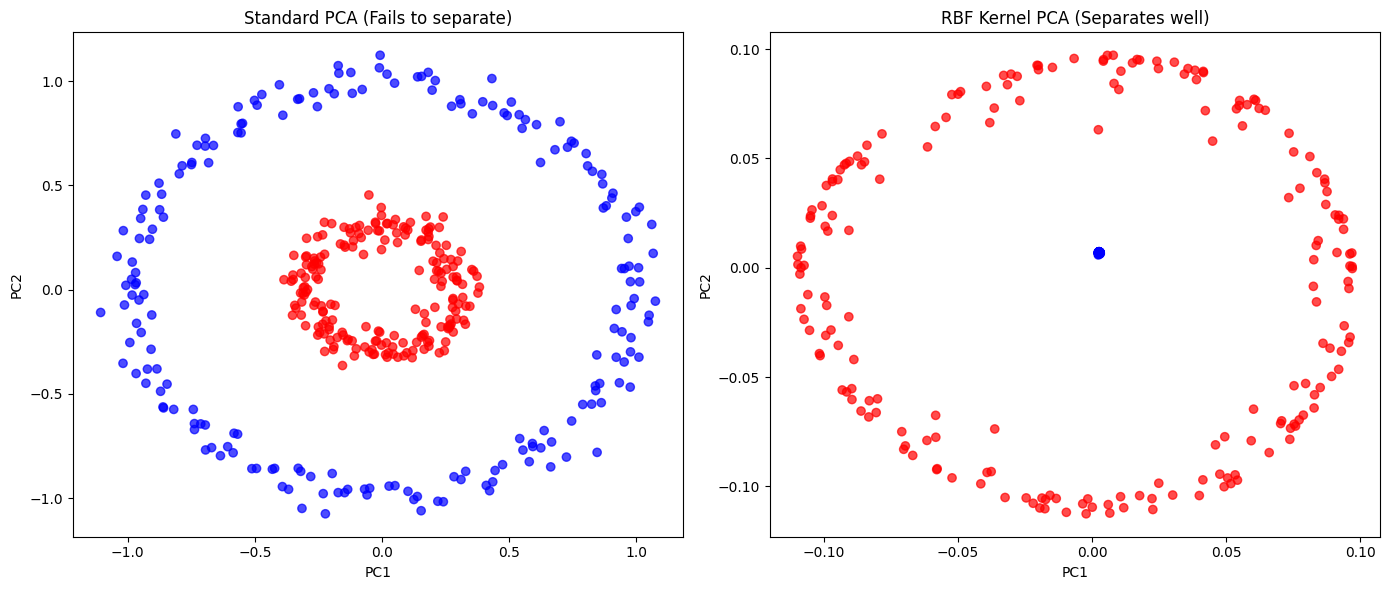

In [6]:

from sklearn.datasets import make_circles
from scipy.spatial.distance import pdist, squareform
from scipy.linalg import eigh

def rbf_kernel_pca(X, gamma, n_components):
    # 1. Calculate pairwise squared Euclidean distances
    sq_dists = pdist(X, 'sqeuclidean')
    mat_sq_dists = squareform(sq_dists)
    
    # 2. Compute the symmetric kernel matrix
    K = np.exp(-gamma * mat_sq_dists)
    
    # 3. Center the kernel matrix
    N = K.shape[0]
    one_n = np.ones((N, N)) / N
    K_centered = K - one_n.dot(K) - K.dot(one_n) + one_n.dot(K).dot(one_n)
    
    # 4. Obtain eigenpairs from the centered kernel matrix
    eigvals, eigenvecs = eigh(K_centered)
    
    # Sort them in decreasing order
    eigvals = eigvals[::-1]
    eigenvecs = eigenvecs[:, ::-1]
    
    # 5. Project the data
    X_pc = eigenvecs[:, :n_components]
    
    return X_pc

# Generate non-linear data
X_circles, y_circles = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=42)

# Apply standard PCA (will fail to separate)
# Assuming a standard PCA class exists or just using sklearn for baseline comparison
from sklearn.decomposition import PCA
pca_standard = PCA(n_components=2)
X_std_pca = pca_standard.fit_transform(X_circles)

# Apply Kernel PCA
X_kpca = rbf_kernel_pca(X_circles, gamma=15, n_components=2)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_std_pca[:, 0], X_std_pca[:, 1], c=y_circles, cmap='bwr', alpha=0.7)
plt.title("Standard PCA (Fails to separate)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(1, 2, 2)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_circles, cmap='bwr', alpha=0.7)
plt.title("RBF Kernel PCA (Separates well)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()
